<font size="5">Section 6: Machine Learning</font>

## Housekeeping and Data

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import eli5
from matplotlib import pyplot as plt
from numpy import mean
from numpy import std
from numpy import absolute

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from pywaffle import Waffle
import scipy
from sklearn.utils import resample,shuffle
import yellowbrick
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from yellowbrick.style import set_palette
from yellowbrick.contrib.wrapper import wrap

%matplotlib inline

## Lasso Regression (Regularization)

In [40]:
df_store=pd.read_csv('../data/ifood_df.csv')
target = df_store.MntTotal
features = df_store.drop('MntTotal', axis=1)
features.describe()

df_bal = resample(df_store[df_store['Response']==1],random_state=42,n_samples=100,replace=True)
df_ups = pd.concat([df_bal,df_store])

In [41]:
df_store.describe()

,Recency,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,49.009070,51622.094785,0.442177,0.506576,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,28.932111,20713.063826,0.537132,0.544380,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,24.000000,35196.000000,0.000000,0.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,49.000000,51287.000000,0.000000,0.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,74.000000,68281.000000,1.000000,1.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,99.000000,113734.000000,2.000000,2.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [42]:
df_store[df_store['Response']==1].describe()

,Recency,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,...,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,35.264264,60209.675676,0.342342,0.306306,502.615616,37.939940,293.765766,51.714715,38.372372,61.252252,...,0.180180,0.054054,0.066066,0.006006,0.456456,0.168168,0.303303,924.408408,863.156156,0.987988
std,27.615407,23194.080987,0.487720,0.493197,427.823621,45.916005,287.120466,61.642623,46.148458,57.484645,...,0.384916,0.226465,0.248771,0.077382,0.498850,0.374578,0.460377,698.913637,682.672587,1.122003
min,0.000000,7500.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,3.000000,0.000000
25%,11.000000,39763.000000,0.000000,0.000000,96.000000,4.000000,47.000000,4.000000,3.000000,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,219.000000,136.000000,0.000000
50%,30.000000,64090.000000,0.000000,0.000000,448.000000,21.000000,170.000000,25.000000,20.000000,39.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,964.000000,858.000000,1.000000
75%,56.000000,80589.000000,1.000000,1.000000,882.000000,53.000000,512.000000,82.000000,57.000000,84.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1517.000000,1441.000000,2.000000
max,99.000000,105471.000000,2.000000,2.000000,1492.000000,193.000000,981.000000,250.000000,198.000000,245.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


In [43]:
df_bal.describe()

,Recency,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,34.790000,59773.130000,0.380000,0.270000,413.800000,34.800000,285.170000,46.910000,37.100000,59.580000,...,0.250000,0.050000,0.070000,0.0,0.440000,0.180000,0.310000,817.780000,758.200000,0.80000
std,25.301533,24249.551009,0.527621,0.489382,387.867128,39.602571,273.032209,59.362624,45.609564,59.683539,...,0.435194,0.219043,0.256432,0.0,0.498888,0.386123,0.464823,660.962255,649.215797,1.03475
min,1.000000,14515.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,14.000000,3.000000,0.00000
25%,11.750000,39389.500000,0.000000,0.000000,90.250000,4.000000,53.500000,4.000000,2.000000,15.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,252.000000,121.000000,0.00000
50%,30.000000,64608.500000,0.000000,0.000000,281.000000,22.000000,182.500000,26.500000,16.000000,39.500000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,673.500000,636.500000,0.00000
75%,56.000000,79738.750000,1.000000,0.250000,716.000000,49.250000,512.000000,64.000000,60.250000,79.250000,...,0.250000,0.000000,0.000000,0.0,1.000000,0.000000,1.000000,1315.000000,1245.500000,1.00000
max,96.000000,105471.000000,2.000000,2.000000,1486.000000,181.000000,951.000000,250.000000,176.000000,219.000000,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,2158.000000,2107.000000,4.00000


<Axes: xlabel='MntTotal', ylabel='Count'>

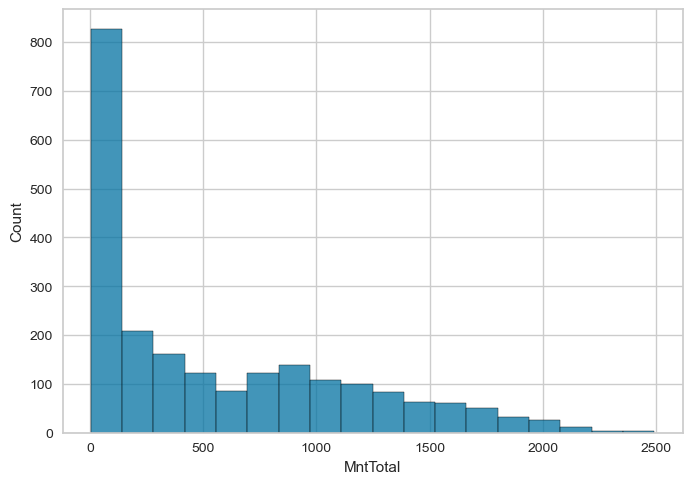

In [44]:
sns.histplot(data=target)

In [45]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# Train the Lasso regression model
lasso=Lasso(alpha=0.1, 
            max_iter=10000,
            tol=0.0001)  # You can adjust the alpha value to control the regularization strength
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1, max_iter=10000)

In [47]:
# Predict on the test set
y_pred = lasso.predict(X_test_scaled)
# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.11499662979613542


In [48]:
y_pred = pd.DataFrame(y_pred, columns=['y_pred'])
y_test = pd.DataFrame(y_test).reset_index(drop=True)
validation = pd.concat([y_test, y_pred], axis=1)
validation.head()

,MntTotal,y_pred
0,2169,2168.861150
1,1059,1058.834745
2,595,595.014762
3,306,306.040322
4,721,720.913596


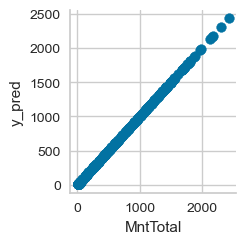

In [49]:
from seaborn_qqplot import pplot
pplot(validation, x="MntTotal", y="y_pred", kind='qq')

In [50]:
# define model evaluation method
cv = RepeatedKFold(n_splits=100, n_repeats=3, random_state=1)
# cross validation scores
scores = cross_val_score(lasso, X_train_scaled, y_train, cv=cv, n_jobs=-1, scoring='neg_root_mean_squared_error')
scores=absolute(scores)
print('Mean RMSE: %.3f (%.3f)' % (mean(scores), std(scores)))

Mean RMSE: 0.120 (0.021)


Feature importance

In [51]:
eli5.show_weights(lasso, top=-1, feature_names = X_train.columns.tolist())

Weight?,Feature
+563.962,<BIAS>
+338.685,MntWines
+216.609,MntMeatProducts
+55.812,MntFishProducts
+41.220,MntSweetProducts
+39.984,MntFruits
+0.418,MntRegularProds
+0.024,NumCatalogPurchases


Tuning alpha

In [52]:
# define model
model = LassoCV(n_alphas=100, cv=cv, n_jobs=-1, max_iter=10000)
# fit model
model.fit(X_train_scaled, y_train)
# summarize chosen configuration
print('alpha: %f' % model.alpha_)

alpha: 0.574118


## Clasification

### Random Forest

In [53]:
target = df_ups.Response
targetr = df_store.Response
features = df_ups.drop('Response', axis=1)
featuresr = df_store.drop('Response', axis=1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
X_trainr, X_testr, y_trainr, y_testr = train_test_split(featuresr, targetr, test_size=0.3, random_state=42)
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the classifier
rf.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf.predict(X_testr)

# Evaluating the accuracy of the classifier
accuracy = accuracy_score(y_testr, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.974320241691843


In [55]:
rf.get_params(deep=True)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [56]:
confusion_matrix(y_testr, y_pred)

array([[565,   6],
       [ 11,  80]], dtype=int64)

Feature importance

<BarContainer object of 38 artists>

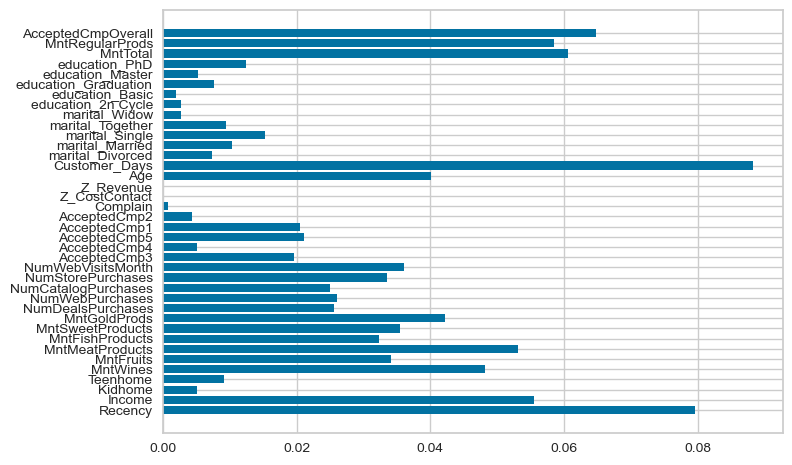

In [57]:
plt.barh(features.columns, rf.feature_importances_)

Now we can turn to tuning the hyperparameters.

In [58]:
from sklearn.model_selection import GridSearchCV

# Create the parameter grid based on the results of random search 
param_grid = {
    'bootstrap': [True],
    'max_depth': [16, 32],
    'max_features': [6, 12],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 6],
    'n_estimators': [100, 200]
}

# Create a based model
rf = RandomForestClassifier()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = 10, n_jobs = -1, verbose = 2)

grid_search.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 48 candidates, totalling 480 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [16, 32],
                         'max_features': [6, 12], 'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 6],
                         'n_estimators': [100, 200]},
             verbose=2)

In [59]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
True_32_12_1_2_100,"{'bootstrap': True, 'max_depth': 32, 'max_feat...",1,0.889058,0.027816
True_16_6_1_2_100,"{'bootstrap': True, 'max_depth': 16, 'max_feat...",2,0.886569,0.020447
True_16_12_1_2_100,"{'bootstrap': True, 'max_depth': 16, 'max_feat...",3,0.885963,0.027460
True_16_12_1_2_200,"{'bootstrap': True, 'max_depth': 16, 'max_feat...",4,0.885346,0.027997
True_32_12_1_2_200,"{'bootstrap': True, 'max_depth': 32, 'max_feat...",5,0.884733,0.026695
True_32_6_1_6_200,"{'bootstrap': True, 'max_depth': 32, 'max_feat...",6,0.884085,0.025658
True_16_6_1_2_200,"{'bootstrap': True, 'max_depth': 16, 'max_feat...",7,0.882862,0.028739
True_32_6_1_2_200,"{'bootstrap': True, 'max_depth': 32, 'max_feat...",7,0.882862,0.025916
True_32_6_1_6_100,"{'bootstrap': True, 'max_depth': 32, 'max_feat...",9,0.882846,0.029211


In [60]:
rf = RandomForestClassifier(
    max_depth=32, max_features=12, min_samples_leaf=1, min_samples_split=2, n_estimators=200, random_state=42)

# Training the classifier
rf.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf.predict(X_testr)

# Evaluating the accuracy of the classifier
accuracy = accuracy_score(y_testr, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9773413897280967


In [61]:
confusion_matrix(y_testr, y_pred)

array([[566,   5],
       [ 10,  81]], dtype=int64)

### Boosting

In [62]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# Making predictions on the test set
y_pred = gb.predict(X_testr)

# Evaluating the accuracy of the classifier
accuracy = accuracy_score(y_testr, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9501510574018127


In [63]:
confusion_matrix(y_testr, y_pred)

array([[562,   9],
       [ 24,  67]], dtype=int64)

Tuning

In [ ]:
## Considerando Grid Search
gb = GradientBoostingClassifier()
parameters = {'learning_rate': [0.02,0.1,0.5],
                  'subsample'    : [0.4, 1],
                  'n_estimators' : [100,200,300],
                  'max_depth'    : [4,6,8]}

grid_GBR = GridSearchCV(estimator=gb, param_grid = parameters, cv = 8, n_jobs=-1)
grid_GBR.fit(X_train_scaled, y_train)   

In [ ]:
results_df = pd.DataFrame(grid_GBR.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
0.02_6_300_1,"{'learning_rate': 0.02, 'max_depth': 6, 'n_est...",1,0.892764,0.025553
0.1_8_300_0.4,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti...",2,0.892120,0.024274
0.1_8_200_0.4,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti...",3,0.891517,0.026817
0.1_6_200_0.4,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",4,0.891495,0.024013
0.5_8_300_1,"{'learning_rate': 0.5, 'max_depth': 8, 'n_esti...",4,0.891495,0.026540
0.1_6_300_0.4,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",6,0.888420,0.024828
0.02_8_300_0.4,"{'learning_rate': 0.02, 'max_depth': 8, 'n_est...",7,0.887798,0.023038
0.1_6_100_0.4,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",7,0.887798,0.026995
0.1_8_100_0.4,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti...",9,0.887795,0.019313


In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=300, subsample=0.4, learning_rate=0.1, max_depth=6, random_state=42).fit(X_train, y_train)

# Making predictions on the test set
y_pred = gb.predict(X_testr)

# Evaluating the accuracy of the classifier
accuracy = accuracy_score(y_testr, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9667673716012085


In [ ]:
confusion_matrix(y_testr, y_pred)

array([[560,  11],
       [ 11,  80]], dtype=int64)

### Support Vector Machine

In [ ]:
from sklearn import svm

svm_m = svm.SVC()
svm_m.fit(X_trainr, y_trainr)

y_pred = svm_m.predict(X_testr)

# Evaluating the accuracy of the classifier
accuracy = accuracy_score(y_testr, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8625377643504532


Tuning

In [ ]:
# defining parameter range
param_grid = {'C': [0.01, 1, 100, 1000], 
              'gamma': [1, 0.1, 0.001, 0.00001],
              'kernel': ['rbf']} 
  
grid_SVM = GridSearchCV(svm_m, param_grid, refit = True, verbose = 3)
  
# fitting the model for grid search
grid_SVM.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 2/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 3/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 4/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.811 total time=   0.0s
[CV 5/5] END .......C=0.01, gamma=1, kernel=rbf;, score=0.807 total time=   0.0s
[CV 1/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 2/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 3/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.808 total time=   0.0s
[CV 4/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.811 total time=   0.0s
[CV 5/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.807 total time=   0.0s
[CV 1/5] END ...C=0.01, gamma=0.001, kernel=rbf;, score=0.808 total time=   0.0s
[CV 2/5] END ...C=0.01, gamma=0.001, kernel=rbf;

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 1, 100, 1000],
                         'gamma': [1, 0.1, 0.001, 1e-05], 'kernel': ['rbf']},
             verbose=3)

In [ ]:
results_df = pd.DataFrame(grid_SVM.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
1_1_rbf,"{'C': 1, 'gamma': 1, 'kernel': 'rbf'}",1,0.866713,0.006961
100_1_rbf,"{'C': 100, 'gamma': 1, 'kernel': 'rbf'}",1,0.866713,0.006961
1000_1_rbf,"{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}",1,0.866713,0.006961
1_0.1_rbf,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",4,0.866094,0.008070
1_0.001_rbf,"{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}",4,0.866094,0.008070
100_0.1_rbf,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}",4,0.866094,0.008070
100_0.001_rbf,"{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}",4,0.866094,0.008070
1000_0.1_rbf,"{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}",4,0.866094,0.008070
1000_0.001_rbf,"{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}",4,0.866094,0.008070


### Stacking

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=16, max_features=8, min_samples_split=8, random_state=42)),
    ('boost', GradientBoostingClassifier(n_estimators=300, learning_rate=0.04, max_depth=8, random_state=42)),
    ('svc', svm.SVC(C=1, gamma=0.0001))]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

stack.fit(X_train, y_train).score(X_testr, y_testr)

0.9712990936555891

In [ ]:
cv = cross_val_score(stack, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)
#print('Accuracy: %.6f' % round(np.mean(cv),6))
print(cv)

[0.89506173 0.85802469 0.83950617 0.9068323  0.9068323  0.88198758
 0.86335404 0.90062112 0.85714286 0.91304348]


## Clustering

### K-means

c:\Users\juanc\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19972\1403927571.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '708312375965.8684' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  param_search.loc[n_clusters, "Inertia"] = KMeans(n_clusters=n_clusters+1, random_state=1).fit(X_train).inertia_
c:\Users\juanc\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\juanc\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `

0    486
2    443
1    357
3    327
Name: count, dtype: int64

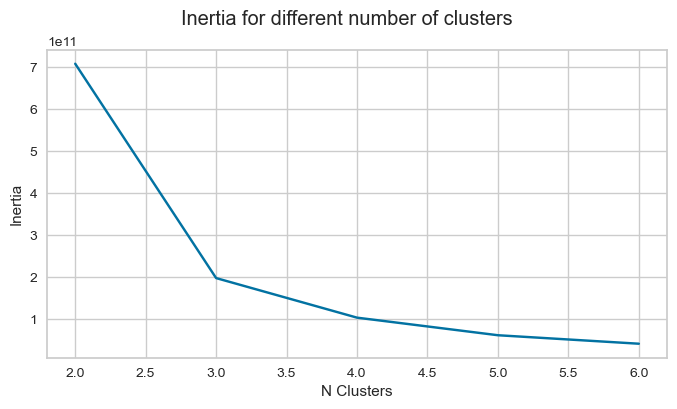

In [ ]:
total_clusters = 5
param_search = pd.DataFrame({
    "N Clusters": np.arange(2,total_clusters+2,dtype=int), 
    "Inertia": [0]*total_clusters
})
for n_clusters in range(total_clusters):
    param_search.loc[n_clusters, "Inertia"] = KMeans(n_clusters=n_clusters+1, random_state=1).fit(X_train).inertia_

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.lineplot(data=param_search, x="N Clusters", y="Inertia", ax=ax)
fig.suptitle("Inertia for different number of clusters")
fig.show()

n_clusters = 4
cluster_labels = pd.Series(KMeans(n_clusters=n_clusters, random_state=1).fit(X_train).labels_)
cluster_labels.value_counts()


c:\Users\juanc\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Text(36.828041574337874, 0.5, 'Income')

<Figure size 1500x800 with 0 Axes>

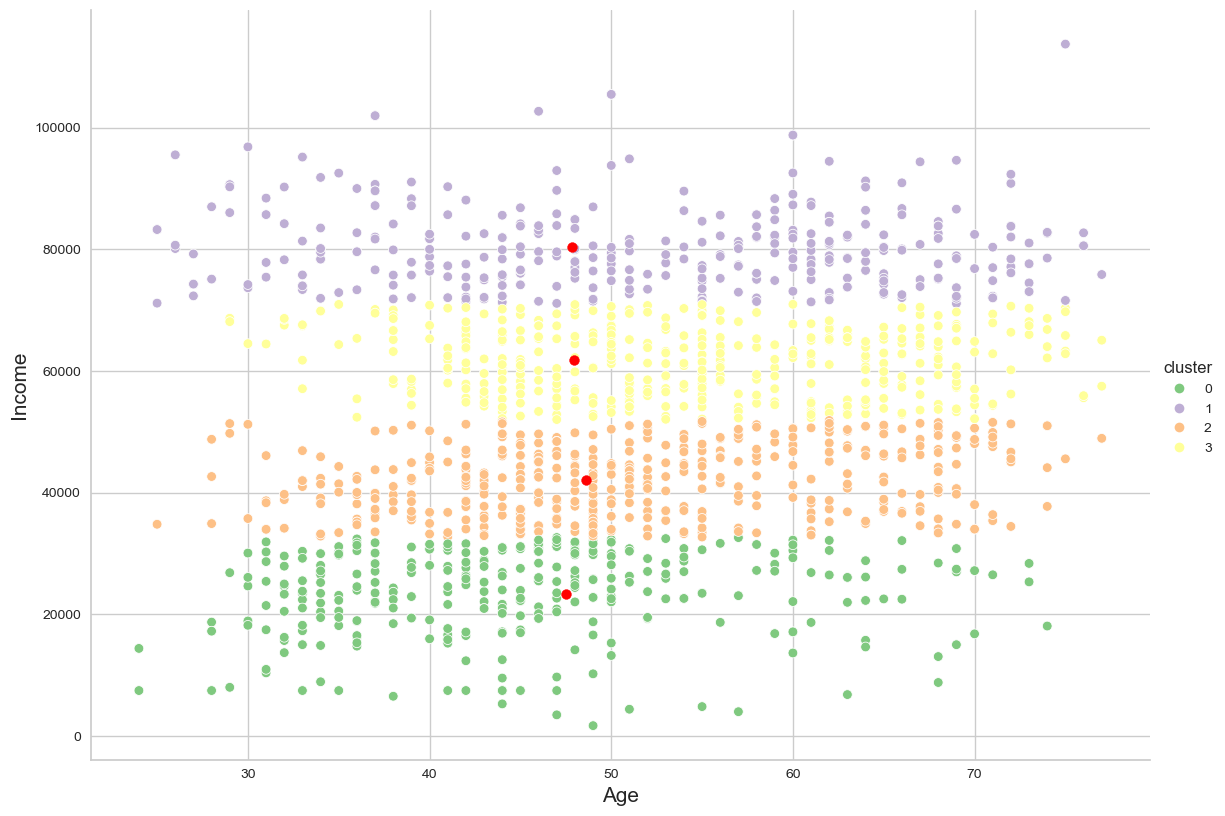

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=32, max_iter=500,n_init=5)
y_kmeans = kmeans.fit_predict(X_train)

kmeans = KMeans(n_clusters=4,init= "random", random_state = 1).fit(X_train)
centroids = kmeans.cluster_centers_
plt.figure(figsize=(15,8))
Data_kmean = X_train.copy()
Data_kmean['cluster'] = kmeans.labels_
sns.relplot(data = Data_kmean ,x='Age' , y  ='Income', hue='cluster', palette='Accent' ,kind='scatter', height=8.27, aspect = 11.7/8.27)
plt.scatter(centroids[:, 0], centroids[:,1], c='red', s=50)
plt.xlabel("Age",fontsize=15)
plt.ylabel("Income",fontsize=15)

### DBSCAN

In [ ]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train)
distances, indices = neighbors_fit.kneighbors(X_train)

Number of clusters: 4


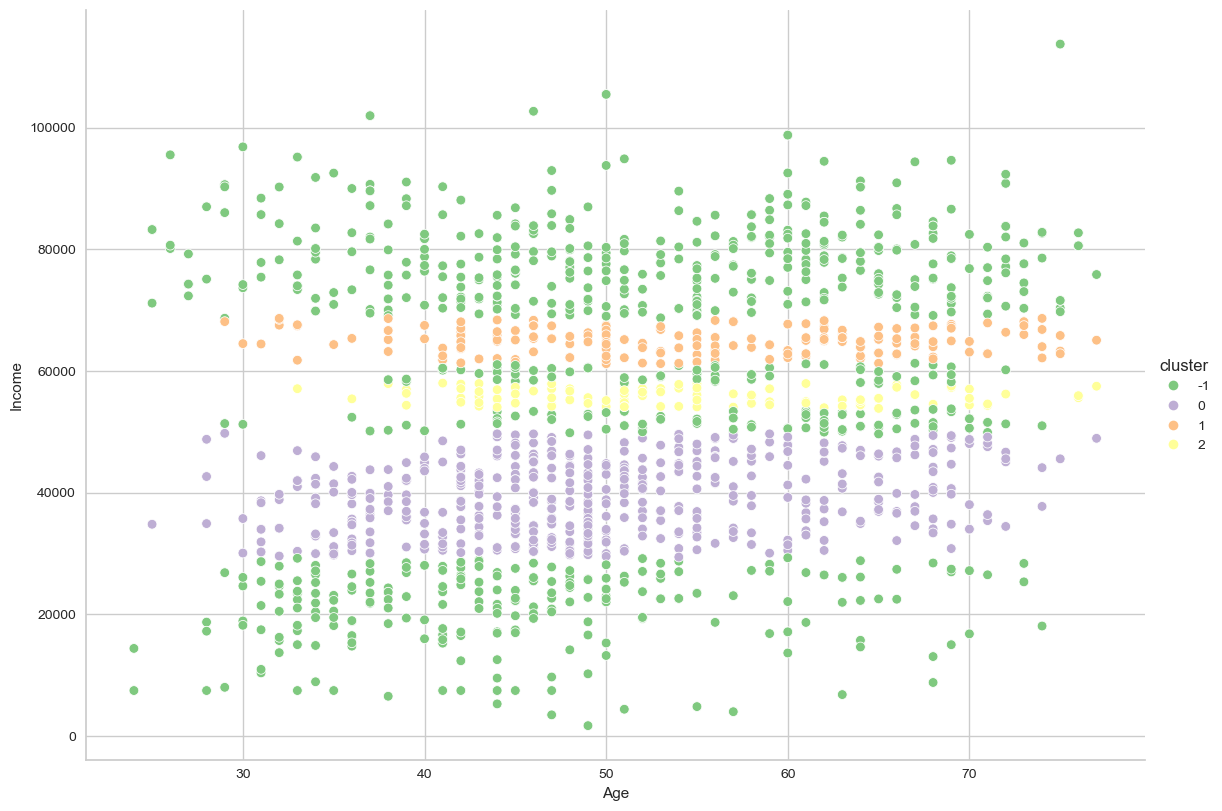

In [ ]:
dbscan = DBSCAN(eps=2100, min_samples=100)
# Fit the DBSCAN model to the data
dbscan.fit(X_train)
# Extract the cluster labels
labels = dbscan.labels_
# Print the number of clusters
n_clusters = len(np.unique(labels))
print(f"Number of clusters: {n_clusters}")

data_dbscan = X_train.copy()
data_dbscan['cluster'] = dbscan.labels_
sns.relplot(data = data_dbscan ,x='Age' , y  ='Income', hue='cluster', palette='Accent' ,kind='scatter', height=8.27, aspect = 11.7/8.27)

<font size="3">**Tarea 4**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 18/7 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos segun indicado en las preguntas (disponibles en la carpeta *data*).

Preguntas:



1. Cargue la base de datos **tweets.csv** y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. En particular, produzca los features que considere necesarios para los modelos de aprendizaje (fechas, hora del dia, ubicacion geografica, aerolinea, etc). En este caso se usaran solo los tweets que se clasifican como "negativos" en variable *airline_sentiment*.

2. Utilice los modelos de clasificacion (Random Forest, Gradient Boosting, SVM, Stacking) vistos en clase para entrenar un modelo que prediga la razon negativa del tweet (variable *negativereason*). Para aquello, agrupe las razones negativas en 4 categorias (basadas en el tipo de problema con el vuelo/aerolinea) y asigne un valor numerico. Ignore celdas vacias y aquellas con respuesta "Can't tell". Justifique la eleccion del modelo y de los hiperparametros.

3. Con el modelo entrenado en la parte anterior, muestre los resultados del ajuste en la muestra de prueba, discutiendo las distintas metricas disponibles. Incluya la matriz de confusion y los features mas relevante en el resultado.

4. Ahora considere usando mas features a partir del texto mismo del tweet. Para ello, revisen el notebook *Sentiment_Analysis.ipynb*, en particular el preproceso del texto del tweet a palabras relevantes:

        def tweet_to_words(tweet):
            letters_only = re.sub(r'#([A-Za-z_À-ÿ]+)', " ",tweet)
            words = letters_only.lower().split()
            stops = set(stopwords.words("english"))
            meaningful_words = [w for w in words if not w in stops]
            return( " ".join( meaningful_words ))
        data['clean_tweet']=data['text'].apply(lambda x: tweet_to_words(x))

Y la creacion de features nuevos a partir del texto del tweet:

        from sklearn.feature_extraction.text import CountVectorizer
        x = data.clean_tweet
        y = data.badreason
        x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
        vect CountVectorizer().fit(x_train)
        x_train_dtm = vect.transform(x_train)

Apliquen el codigo comentado aqui para generar un set de features a partir de las palabras relevantes del texto cada tweet. Discuta las palabras mas relevantes por categoria de problema (segun lo definido en la parte 2).

5. Con los features de la parte anterior, estime un modelo de clasificacion similar a la parte 2, discuta sus resultados, comparandolos con aquellos de la parte 3.

6. Ahora considere una clasificacion a partir de un modelo pre-entrenado como BERT, tal como se discute en el notebook *Transformers.ipynb*. En particular, cargue el modelo BERT base:

        model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

Usando la misma estructura de datos de la parte anterior, haga un ajuste fino (fine tuning) el modelo BERT pre-entrenado para clasificar las razones negativas del tweet, y evalue su ajuste, comparando con la parte 5. Para hacer el ajuste fino, puede usar la funcion Trainer (https://huggingface.co/transformers/v3.3.1/training.html). 